In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX",
    "RM", "AGE", "DIS", "RAD", "TAX",
    "PTRATIO", "B", "LSTAT", "MEDV",
]



In [18]:
import pandas as pd

data = pd.read_csv("housing.csv")

In [19]:
print(data.head())

   Unnamed: 0     crim    zn  indus  chas    nox     rm   age     dis  rad  \
0           1  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1   
1           2  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2   
2           3  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2   
3           4  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3   
4           5  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3   

   tax  ptratio   black  lstat  medv  
0  296     15.3  396.90   4.98  24.0  
1  242     17.8  396.90   9.14  21.6  
2  242     17.8  392.83   4.03  34.7  
3  222     18.7  394.63   2.94  33.4  
4  222     18.7  396.90   5.33  36.2  


In [21]:
print(data.shape)

(506, 15)


In [22]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  black       506 non-null    float64
 13  lstat       506 non-null    float64
 14  medv        506 non-null    float64
dtypes: float64(11), int64(4)
memory usage: 59.4 KB
None


In [23]:
print(data.describe())

       Unnamed: 0        crim          zn       indus        chas         nox  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean   253.500000    3.613524   11.363636   11.136779    0.069170    0.554695   
std    146.213884    8.601545   23.322453    6.860353    0.253994    0.115878   
min      1.000000    0.006320    0.000000    0.460000    0.000000    0.385000   
25%    127.250000    0.082045    0.000000    5.190000    0.000000    0.449000   
50%    253.500000    0.256510    0.000000    9.690000    0.000000    0.538000   
75%    379.750000    3.677083   12.500000   18.100000    0.000000    0.624000   
max    506.000000   88.976200  100.000000   27.740000    1.000000    0.871000   

               rm         age         dis         rad         tax     ptratio  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     6.284634   68.574901    3.795043    9.549407  408.237154   18.455534   
std      0.702617   28.1488

In [24]:
print(data.isnull().sum())

Unnamed: 0    0
crim          0
zn            0
indus         0
chas          0
nox           0
rm            0
age           0
dis           0
rad           0
tax           0
ptratio       0
black         0
lstat         0
medv          0
dtype: int64


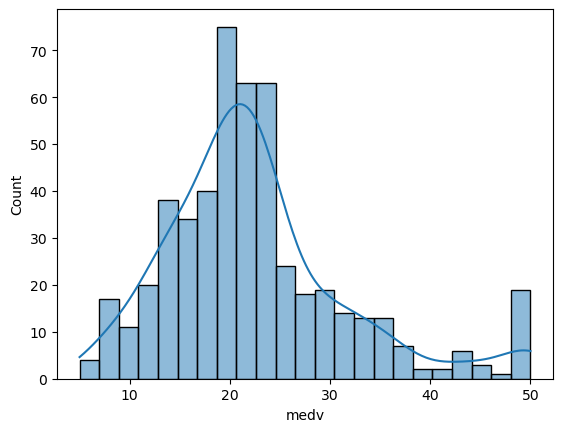

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data["medv"], kde=True)
plt.show()

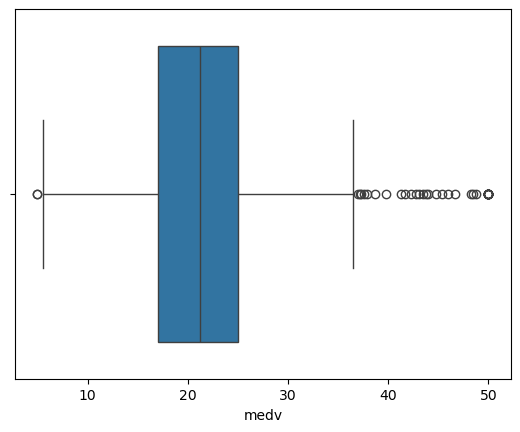

In [28]:
sns.boxplot(x=data["medv"])
plt.show()

In [29]:
correlation = data.corr()

In [30]:
plt.figure(figsize = (12,10))

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

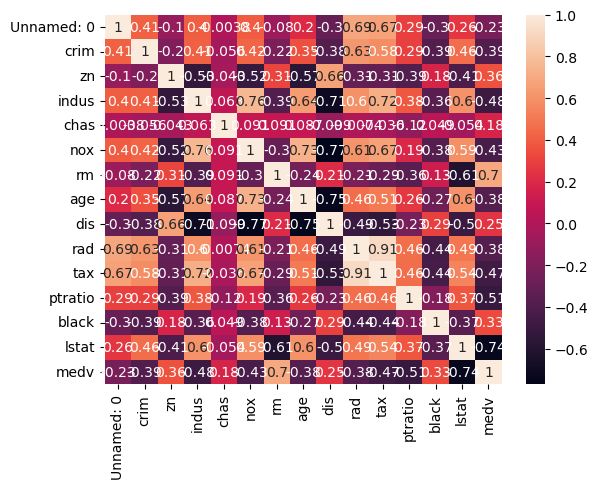

In [31]:
sns.heatmap(correlation, annot = True)
plt.show()


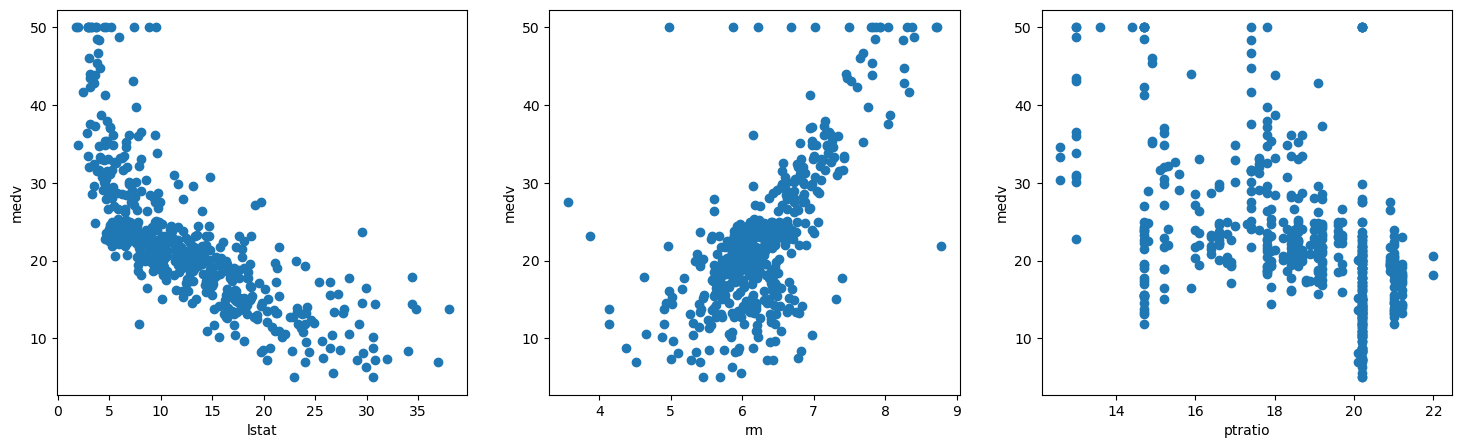

In [36]:
import matplotlib.pyplot as plt

features = ['lstat', 'rm', 'ptratio']   

plt.figure(figsize=(18,5))

for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    plt.scatter(data[col], data["medv"])   
    plt.xlabel(col)
    plt.ylabel("medv")

plt.show()

In [37]:
x = data.iloc[:,:-1]
y = data["medv"]

In [38]:
#Train - test split

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)


In [39]:
# Normalization

mean = x_train.mean()
std = x_train.std()

In [40]:
x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

In [41]:
# Linear Regression Model

from sklearn.linear_model import LinearRegression
model_lr = LinearRegression()
model_lr.fit(x_train, y_train) 

y_pred = model_lr.predict(x_test)

In [44]:
# Evaluation

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [50]:
print("RMSE:" , rmse)

RMSE: 4.9495272276885585


In [51]:
print("MAE:" , mae)

MAE: 3.200754757340821


In [52]:
print("R2 Score:" , r2)

R2 Score: 0.6659408703343036


In [56]:
! pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable


In [59]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split
X = data.drop("medv", axis=1)
y = data["medv"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.05,
    verbose=2
)

C:\Users\darsh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
12/12 - 6s - 484ms/step - loss: 587.1400 - mae: 22.3269 - val_loss: 478.5351 - val_mae: 20.3740
Epoch 2/20
12/12 - 0s - 32ms/step - loss: 507.6965 - mae: 20.4929 - val_loss: 370.5788 - val_mae: 17.6544
Epoch 3/20
12/12 - 0s - 31ms/step - loss: 343.2296 - mae: 16.0435 - val_loss: 176.2111 - val_mae: 11.1737
Epoch 4/20
12/12 - 0s - 33ms/step - loss: 123.6157 - mae: 8.7203 - val_loss: 57.1792 - val_mae: 5.0537
Epoch 5/20
12/12 - 0s - 34ms/step - loss: 75.0468 - mae: 6.9023 - val_loss: 48.3837 - val_mae: 4.4788
Epoch 6/20
12/12 - 0s - 34ms/step - loss: 38.7585 - mae: 4.7113 - val_loss: 53.2119 - val_mae: 4.6319
Epoch 7/20
12/12 - 0s - 34ms/step - loss: 27.2104 - mae: 3.7883 - val_loss: 48.5023 - val_mae: 4.7482
Epoch 8/20
12/12 - 0s - 30ms/step - loss: 21.3878 - mae: 3.3194 - val_loss: 50.4848 - val_mae: 4.6016
Epoch 9/20
12/12 - 0s - 32ms/step - loss: 18.8890 - mae: 3.0733 - val_loss: 50.8477 - val_mae: 4.5346
Epoch 10/20
12/12 - 0s - 28ms/step - loss: 17.7966 - mae: 3.0351 - v

In [77]:
mse_nn, mae_nn = model.evaluate(X_test, y_test)

print("NN MSE:", mse_nn)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 15.0401 - mae: 2.6076
NN MSE: 15.040080070495605


In [78]:
print("NN MAE:", mae_nn)

NN MAE: 2.6076321601867676


In [83]:
new_data = sc.transform([[0, 0.1,10,5,0,0.4,6,50,6,1,400,20,300,10]])

prediction = model.predict(new_data)

print("Predicted house price:", prediction)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
Predicted house price: [[20.023493]]
